# Stroke Prediction
Professional training notebook for MediPredictAI.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
print("Libraries imported")

Libraries imported


In [2]:
df = pd.read_csv("../datasets/stroke/healthcare-dataset-stroke-data.csv")
print(df.shape)
df.head()

(5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_ty

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,5110.0,NaN,NaN,NaN,36517.829354,21161.721625,67.0,17741.25,36932.0,54682.0,72940.0
gender,5110,3,Female,2994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5110.0,NaN,NaN,NaN,43.226614,22.612647,0.08,25.0,45.0,61.0,82.0
hypertension,5110.0,NaN,NaN,NaN,0.097456,0.296607,0.0,0.0,0.0,0.0,1.0
heart_disease,5110.0,NaN,NaN,NaN,0.054012,0.226063,0.0,0.0,0.0,0.0,1.0
ever_married,5110,2,Yes,3353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_type,5110,5,Private,2925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Residence_type,5110,2,Urban,2596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_glucose_level,5110.0,NaN,NaN,NaN,106.147677,45.28356,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,NaN,NaN,NaN,28.893237,7.854067,10.3,23.5,28.1,33.1,97.6


stroke
0    4861
1     249
Name: count, dtype: int64


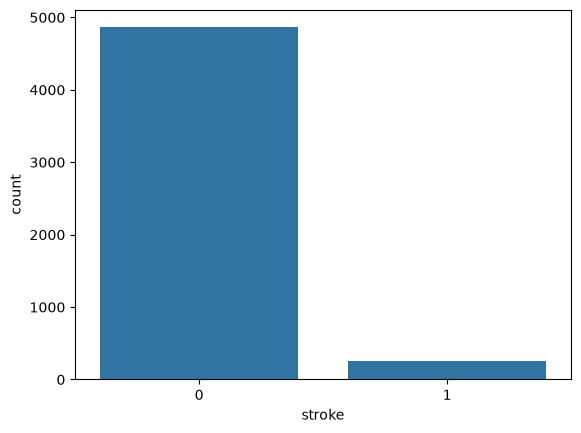

In [5]:
print(df["stroke"].value_counts())
sns.countplot(data=df,x="stroke")
plt.show()

In [6]:
df=df.drop("id",axis=1)

imputer=SimpleImputer(strategy="median")
df["bmi"]=imputer.fit_transform(df[["bmi"]])

categorical=[
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

df=pd.get_dummies(df,columns=categorical,drop_first=True)

X=df.drop("stroke",axis=1)
y=df["stroke"]

feature_columns=X.columns.tolist()

print("Shape:",X.shape)
print("NaN:",X.isnull().sum().sum())

Shape: (5110, 16)
NaN: 0


In [7]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

models={
"Logistic Regression":LogisticRegression(max_iter=1000,class_weight="balanced",random_state=42),
"Decision Tree":DecisionTreeClassifier(class_weight="balanced",random_state=42),
"Random Forest":RandomForestClassifier(n_estimators=300,class_weight="balanced",random_state=42),
"KNN":KNeighborsClassifier(),
"SVM":SVC(probability=True,class_weight="balanced",random_state=42),
"Naive Bayes":GaussianNB()
}

results=[]

for name,model in models.items():
    model.fit(X_train_scaled,y_train)
    pred=model.predict(X_test_scaled)
    results.append({
        "Model":name,
        "Accuracy":accuracy_score(y_test,pred),
        "Precision":precision_score(y_test,pred,zero_division=0),
        "Recall":recall_score(y_test,pred,zero_division=0),
        "F1 Score":f1_score(y_test,pred,zero_division=0)
    })

results_df=pd.DataFrame(results).sort_values("F1 Score",ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.745597,0.137931,0.80,0.235294
1,SVM,0.773973,0.136546,0.68,0.227425
2,Random Forest,0.934442,0.185185,0.10,0.129870
3,Decision Tree,0.929550,0.156250,0.10,0.121951
4,Naive Bayes,0.185910,0.055682,0.98,0.105376
5,KNN,0.948141,0.200000,0.02,0.036364


Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022



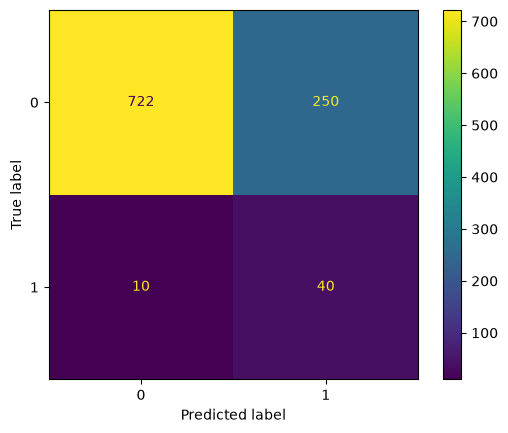

ROC AUC: 0.8438065843621398


In [8]:
best_model_name=results_df.iloc[0]["Model"]
best_model=models[best_model_name]

pred=best_model.predict(X_test_scaled)

print(best_model_name)
print(classification_report(y_test,pred,zero_division=0))

cm=confusion_matrix(y_test,pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

prob=best_model.predict_proba(X_test_scaled)[:,1]
print("ROC AUC:",roc_auc_score(y_test,prob))

In [9]:
MODEL_DIR=Path("../trained_models")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(best_model,MODEL_DIR/"stroke_model.pkl")
joblib.dump(scaler,MODEL_DIR/"stroke_scaler.pkl")
joblib.dump(feature_columns,MODEL_DIR/"stroke_columns.pkl")

print("Saved successfully")

Saved successfully
